In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model

# Keras imports
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from keras import backend as K
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.utils import plot_model


In [ ]:
df=pd.read_csv("/content/RELIANCE.csv",na_values=['null'],index_col='Date',parse_dates=True,infer_datetime_format=True)
df.head()

<ipython-input-10-cd7e2ca22e74>:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df=pd.read_csv("/content/RELIANCE.csv",na_values=['null'],index_col='Date',parse_dates=True,infer_datetime_format=True)


,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [ ]:
#Print the shape of Dataframe  and Check for Null Values
print("Dataframe Shape:", df.shape)
print("Null Value Present:" , df.isnull().values.any())

Dataframe Shape: (5306, 14)
Null Value Present: True


<Axes: xlabel='Date'>

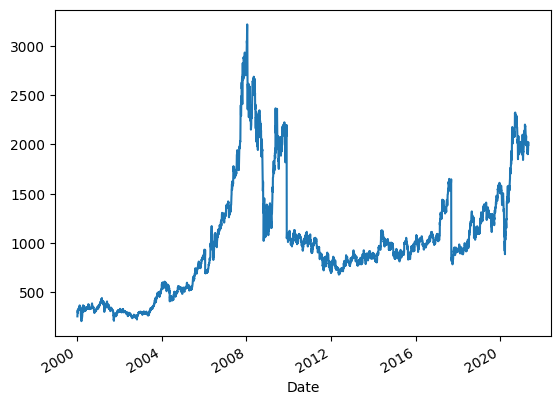

In [ ]:
df["Close"].plot()

In [ ]:
#Set Target Variable
output_var = pd.DataFrame(df["Close"])
#Selecting the Features
features = ["Open", "High","Low","Volume"]

In [ ]:
scaler = MinMaxScaler()
feature_transform = scaler.fit_transform(df[features])
feature_transform= pd.DataFrame(columns=features, data=feature_transform, index=df.index)
feature_transform.head()

,Open,High,Low,Volume
Date,,,,
2000-01-03,0.010348,0.010460,0.013705,0.067563
2000-01-04,0.017106,0.017005,0.018392,0.144758
2000-01-05,0.016540,0.022219,0.020210,0.410888
2000-01-06,0.027001,0.026376,0.031197,0.239796
2000-01-07,0.028941,0.031964,0.032556,0.304062


In [ ]:
#Splitting to Training set and Test set
timesplit= TimeSeriesSplit(n_splits=10)
for train_index, test_index in timesplit.split(feature_transform):
        X_train, X_test = feature_transform[:len(train_index)], feature_transform[len(train_index): (len(train_index)+len(test_index))]
        y_train, y_test = output_var[:len(train_index)].values.ravel(), output_var[len(train_index): (len(train_index)+len(test_index))].values.ravel()

In [ ]:
#Process the data for LSTM
trainX =np.array(X_train)
testX =np.array(X_test)
X_train = trainX.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = testX.reshape(X_test.shape[0], 1, X_test.shape[1])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


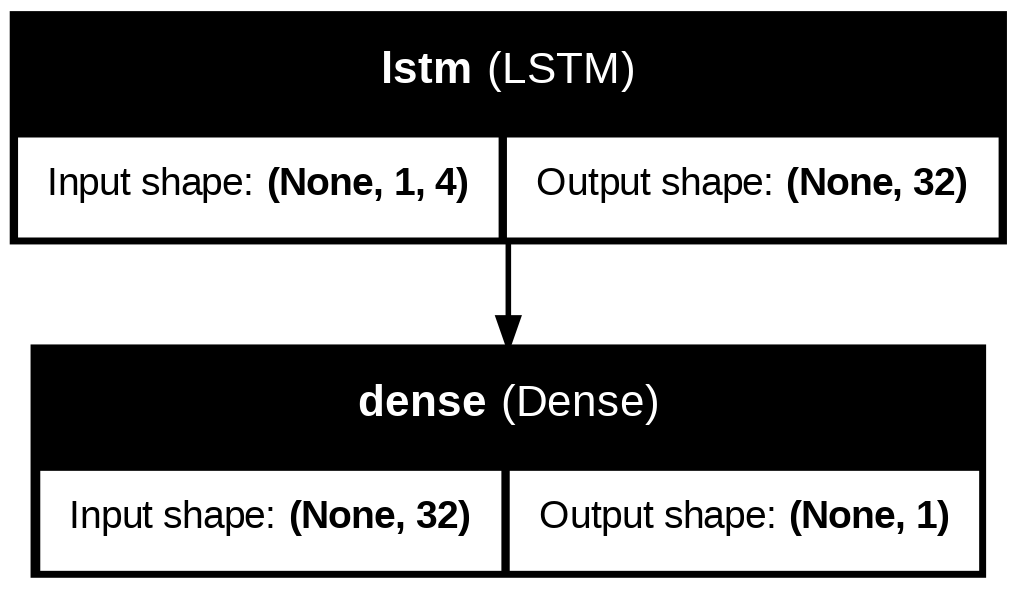

In [ ]:
#Building the LSTM Model
lstm = Sequential()
lstm.add(LSTM(32, input_shape=(1, trainX.shape[1]), activation="relu", return_sequences=False))
lstm.add(Dense(1))
lstm.compile(loss="mean_squared_error", optimizer="adam")
plot_model(lstm, show_shapes=True, show_layer_names=True)

In [ ]:
history=lstm.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1, shuffle=False)

Epoch 1/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 784767.5625
Epoch 2/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 752345.4375
Epoch 3/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 689224.4375
Epoch 4/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 607217.6250
Epoch 5/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 518045.6250
Epoch 6/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 429914.7188
Epoch 7/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 348721.2500
Epoch 8/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 278577.5625
Epoch 9/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 221952.5469
Epoch 10/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 179669.4531
Epoch 11/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 150856.8281
Epoch 12/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 133170.4844
Epoch 13/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 123018.8125
Epoch 14/100
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 1m

In [ ]:
#LSTM Prediction
y_pred= lstm.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


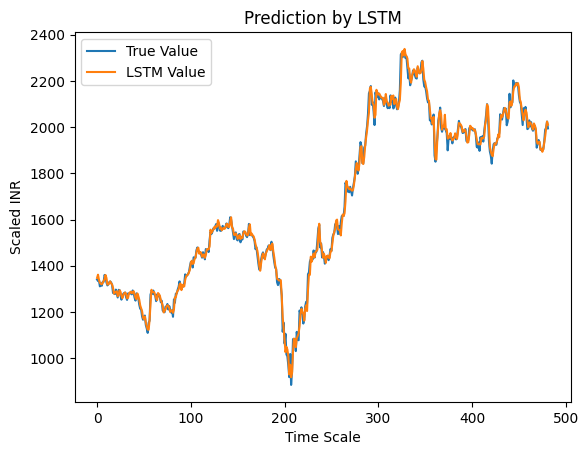

In [ ]:
#Predicted vs True Adj Close Value – LSTM
plt.plot(y_test, label="True Value")
plt.plot(y_pred, label="LSTM Value")
plt.title("Prediction by LSTM")
plt.xlabel("Time Scale")
plt.ylabel("Scaled INR")
plt.legend()
plt.show()